In [1]:
# Library Importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from itertools import combinations
import warnings
import os
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
from reportlab.lib.pagesizes import letter
from reportlab.lib.units import inch
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Table, 
                                TableStyle, PageBreak, Image as RLImage)
from reportlab.graphics.shapes import Drawing
from reportlab.graphics.charts.barcharts import HorizontalBarChart
from datetime import datetime
import io

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 1: CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

class OEFFModelConfig:
    """Configuration for OEFF prediction model"""
    TARGET = 'OEFF'
    EXCLUDE = {'Player', 'Team', 'Year', 'POS', 'OEFF'}
    TOP_N = 8                           # Top N features for subset search
    CORR_THRESHOLD = 0.2                # Minimum |correlation| with OEFF
    CV_FOLDS = 5                        # Cross-validation folds
    RANDOM_STATE = 42
    SEARCH_MODE = 'forward'             # 'forward' or 'exhaustive'
    RF_N_ESTIMATORS = 100               # Random Forest trees
    N_JOBS = -1                         # CPU cores (-1 = all)
    
    # Output files
    MODEL_REPORT = 'oeff_model_report.pdf'
    RESULTS_CSV = 'oeff_model_results_2021_2025.csv'
    PREDICTIONS_CSV = 'player_predictions.csv'

config = OEFFModelConfig()

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 2: DATA LOADING AND PREPARATION
# ═══════════════════════════════════════════════════════════════════════════════

def load_and_prepare_data(filepath='data.csv'):
    """
    Load and prepare player data for modeling
    
    Args:
        filepath: Path to CSV file with player statistics
        
    Returns:
        df_clean: Cleaned dataframe ready for modeling
        metadata: Dictionary with data information
    """
    print("=" * 70)
    print("LOADING AND PREPARING DATA")
    print("=" * 70)
    
    # Load data
    df = pd.read_csv(filepath)
    print(f"✓ Loaded {len(df)} rows from {filepath}")
    print(f"✓ Columns: {list(df.columns)}\n")
    
    # Replace null placeholders
    NULL_PLACEHOLDERS = ['--', '-', 'N/A', 'n/a', 'NA', 'null', 'none', 'None', '']
    df.replace(NULL_PLACEHOLDERS, np.nan, inplace=True)
    
    # Convert all non-excluded columns to numeric
    for col in df.columns:
        if col not in config.EXCLUDE:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # ── Filter: minimum games played ──────────────────────────────────────
    if 'G' in df.columns:
        before = len(df)
        df = df[df['G'] > 3].copy()
        print(f"✓ Games filter (G > 3): {before} → {len(df)} rows ({before - len(df)} removed)")
    else:
        print("⚠  Column 'G' not found — games filter skipped")
    
    # Convert all non-excluded columns to numeric
    for col in df.columns:
        if col not in config.EXCLUDE:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Identify candidate features
    candidate_features = [c for c in df.columns
                         if c not in config.EXCLUDE and pd.api.types.is_numeric_dtype(df[c])]
    
    # Create clean dataset
    df_clean = df[candidate_features + [config.TARGET]].dropna()
    
    print(f"✓ Candidate features ({len(candidate_features)}): {candidate_features}")
    print(f"✓ Rows after cleaning: {len(df_clean)}")
    print(f"✓ Target variable: {config.TARGET}\n")
    
    # Store metadata for later use
    metadata = {
        'original_rows': len(df),
        'clean_rows': len(df_clean),
        'candidate_features': candidate_features,
        'original_df': df  # Keep for predictions later
    }
    
    return df_clean, metadata

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 3: CORRELATION ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════

def analyze_correlations(df_clean, metadata):
    """
    Analyze feature correlations with target and filter by threshold
    
    Args:
        df_clean: Cleaned dataframe
        metadata: Dictionary to update with correlation info
        
    Returns:
        filtered_features: List of features passing correlation threshold
        corr_results: Series of correlations
    """
    print("=" * 70)
    print(f"CORRELATION ANALYSIS (threshold = |r| >= {config.CORR_THRESHOLD})")
    print("=" * 70)
    
    candidate_features = metadata['candidate_features']
    
    # Calculate correlations
    corr_with_target = (
        df_clean[candidate_features + [config.TARGET]]
        .corr()[config.TARGET]
        .drop(config.TARGET)
        .abs()
        .sort_values(ascending=False)
    )
    
    print("\nCorrelations with OEFF:")
    print(corr_with_target.to_string())
    
    # Filter by threshold
    if config.CORR_THRESHOLD > 0.0:
        filtered_features = corr_with_target[corr_with_target >= config.CORR_THRESHOLD].index.tolist()
        dropped = corr_with_target[corr_with_target < config.CORR_THRESHOLD].index.tolist()
        
        print(f"\n✓ Kept ({len(filtered_features)}): {filtered_features}")
        print(f"✗ Dropped ({len(dropped)}): {dropped}")
        
        if len(filtered_features) == 0:
            raise ValueError(
                f"No features passed correlation threshold {config.CORR_THRESHOLD}. "
                "Lower the threshold in config."
            )
    else:
        filtered_features = candidate_features
        print("\n✓ Correlation filter disabled - using all features")
    
    # Visualize correlations
    plt.figure(figsize=(10, max(4, len(corr_with_target) * 0.3)))
    colors_list = ['#27ae60' if f in filtered_features else '#e74c3c' 
                   for f in corr_with_target.index]
    plt.barh(corr_with_target.index, corr_with_target.values, color=colors_list, alpha=0.7)
    plt.xlabel('|Correlation with OEFF|', fontsize=11)
    plt.title('Feature Correlations with OEFF', fontsize=13, fontweight='bold')
    plt.axvline(x=config.CORR_THRESHOLD, color='red', linestyle='--', 
                label=f'Threshold = {config.CORR_THRESHOLD}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    metadata['corr_results'] = corr_with_target
    metadata['filtered_features'] = filtered_features
    
    return filtered_features, corr_with_target

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 4: MODEL EVALUATION UTILITIES
# ═══════════════════════════════════════════════════════════════════════════════

def evaluate_model(X, y, model, cv=None):
    """
    Evaluate model using cross-validation
    
    Args:
        X: Feature matrix
        y: Target vector
        model: Sklearn model
        cv: Cross-validation splitter
        
    Returns:
        mean_r2: Mean R² score
        mean_rmse: Mean RMSE
    """
    if cv is None:
        cv = KFold(n_splits=config.CV_FOLDS, shuffle=True, random_state=config.RANDOM_STATE)
    
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    r2_scores = cross_val_score(pipe, X, y, cv=cv, scoring='r2', n_jobs=config.N_JOBS)
    mse_scores = cross_val_score(pipe, X, y, cv=cv, 
                                 scoring='neg_mean_squared_error', n_jobs=config.N_JOBS)
    
    return r2_scores.mean(), np.sqrt(-mse_scores.mean())

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 5: BASELINE MODELS
# ═══════════════════════════════════════════════════════════════════════════════

def train_baseline_models(df_clean, features):
    """
    Train and evaluate baseline models on all features
    
    Args:
        df_clean: Cleaned dataframe
        features: List of feature names to use
        
    Returns:
        baseline_results: List of result dictionaries
    """
    print("\n" + "=" * 70)
    print("BASELINE MODELS (All Features)")
    print("=" * 70)
    
    X = df_clean[features].values
    y = df_clean[config.TARGET].values
    
    models = {
        'LinearRegression': LinearRegression(),
        'Ridge(α=1)': Ridge(alpha=1, random_state=config.RANDOM_STATE),
        'Lasso(α=0.01)': Lasso(alpha=0.01, max_iter=5000, random_state=config.RANDOM_STATE),
        'RandomForest': RandomForestRegressor(n_estimators=config.RF_N_ESTIMATORS, 
                                             random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=100, 
                                                     random_state=config.RANDOM_STATE),
    }
    
    results = []
    print(f"\nEvaluating {len(models)} models with {len(features)} features...\n")
    
    for name, model in models.items():
        r2, rmse = evaluate_model(X, y, model)
        results.append({
            'Model': name,
            'Features': 'ALL',
            'n_features': len(features),
            'CV_R2': round(r2, 4),
            'CV_RMSE': round(rmse, 4)
        })
        print(f"  {name:<25} R² = {r2:.4f}  |  RMSE = {rmse:.4f}")
    
    # Visualize results
    results_df = pd.DataFrame(results).sort_values('CV_R2', ascending=True)
    
    plt.figure(figsize=(10, 5))
    plt.barh(results_df['Model'], results_df['CV_R2'], color='steelblue', alpha=0.7)
    plt.xlabel('Cross-Validated R²', fontsize=11)
    plt.title('Baseline Model Performance', fontsize=13, fontweight='bold')
    plt.xlim(0, 1)
    for i, (idx, row) in enumerate(results_df.iterrows()):
        plt.text(row['CV_R2'] + 0.01, i, f"{row['CV_R2']:.4f}", va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    
    return results

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 6: FEATURE IMPORTANCE
# ═══════════════════════════════════════════════════════════════════════════════

def analyze_feature_importance(df_clean, features):
    """
    Analyze feature importance using Random Forest
    
    Args:
        df_clean: Cleaned dataframe
        features: List of feature names
        
    Returns:
        importances: Series of feature importances
        top_features: List of top N features
    """
    print("\n" + "=" * 70)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("=" * 70)
    
    X = df_clean[features].values
    y = df_clean[config.TARGET].values
    
    # Train Random Forest
    rf = RandomForestRegressor(n_estimators=200, random_state=config.RANDOM_STATE, 
                              n_jobs=config.N_JOBS)
    rf.fit(StandardScaler().fit_transform(X), y)
    
    # Get importances
    importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
    top_features = importances.head(config.TOP_N).index.tolist()
    
    print("\nFeature Importances:")
    print(importances.to_string())
    print(f"\n✓ Top {config.TOP_N} features selected for subset search: {top_features}")
    
    # Visualize
    plt.figure(figsize=(10, max(4, len(importances) * 0.3)))
    colors_list = ['#2ecc71' if f in top_features else '#95a5a6' for f in importances.index]
    plt.barh(importances.index, importances.values, color=colors_list, alpha=0.7)
    plt.xlabel('Importance', fontsize=11)
    plt.title('Random Forest Feature Importances', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return importances, top_features

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 7: FEATURE SUBSET SEARCH
# ═══════════════════════════════════════════════════════════════════════════════

def forward_selection(df_clean, features, model_name, model, max_features):
    """
    Greedy forward feature selection
    
    Args:
        df_clean: Cleaned dataframe
        features: List of features to choose from
        model_name: Name of model
        model: Sklearn model
        max_features: Maximum features to select
        
    Returns:
        results: List of result dictionaries
    """
    y = df_clean[config.TARGET].values
    selected, remaining = [], list(features)
    results = []
    
    for step in range(min(max_features, len(features))):
        best_r2, best_feat = -np.inf, None
        
        for feat in remaining:
            candidate = selected + [feat]
            X_sub = df_clean[candidate].values
            r2, rmse = evaluate_model(X_sub, y, model)
            
            results.append({
                'Model': model_name,
                'Features': candidate.copy(),
                'n_features': len(candidate),
                'CV_R2': round(r2, 4),
                'CV_RMSE': round(rmse, 4)
            })
            
            if r2 > best_r2:
                best_r2, best_feat = r2, feat
        
        if best_feat is None:
            break
            
        selected.append(best_feat)
        remaining.remove(best_feat)
    
    return results

def search_feature_subsets(df_clean, top_features):
    """
    Search for best feature subsets using forward selection or exhaustive search
    
    Args:
        df_clean: Cleaned dataframe
        top_features: List of top features to search
        
    Returns:
        all_results: List of all result dictionaries
        best_result: Dictionary with best result
    """
    print("\n" + "=" * 70)
    print(f"FEATURE SUBSET SEARCH (mode: {config.SEARCH_MODE})")
    print("=" * 70)
    
    search_models = {
        'LinearRegression': LinearRegression(),
        'Ridge(α=1)': Ridge(alpha=1, random_state=config.RANDOM_STATE),
        'RandomForest': RandomForestRegressor(n_estimators=config.RF_N_ESTIMATORS,
                                             random_state=config.RANDOM_STATE, 
                                             n_jobs=config.N_JOBS),
    }
    
    all_results = []
    
    if config.SEARCH_MODE == 'forward':
        print(f"\nRunning forward selection with {len(search_models)} models...")
        for model_name, model in search_models.items():
            print(f"  → {model_name}...")
            results = forward_selection(df_clean, top_features, model_name, model, config.TOP_N)
            all_results.extend(results)
        print(f"✓ Forward selection complete ({len(all_results)} evaluations)")
        
    else:  # exhaustive
        y = df_clean[config.TARGET].values
        print(f"\nRunning exhaustive search...")
        total = sum(len(list(combinations(top_features, size))) 
                   for size in range(2, config.TOP_N + 1)) * len(search_models)
        print(f"  → Testing {total} combinations...")
        
        for size in range(2, config.TOP_N + 1):
            for feat_combo in combinations(top_features, size):
                X_sub = df_clean[list(feat_combo)].values
                for model_name, model in search_models.items():
                    r2, rmse = evaluate_model(X_sub, y, model)
                    all_results.append({
                        'Model': model_name,
                        'Features': list(feat_combo),
                        'n_features': len(feat_combo),
                        'CV_R2': round(r2, 4),
                        'CV_RMSE': round(rmse, 4)
                    })
        print(f"✓ Exhaustive search complete ({len(all_results)} evaluations)")
    
    # Find best result
    results_df = pd.DataFrame(all_results)
    best_result = results_df.sort_values('CV_R2', ascending=False).iloc[0].to_dict()
    
    print(f"\n🏆 BEST MODEL FOUND:")
    print(f"   Model: {best_result['Model']}")
    print(f"   Features ({best_result['n_features']}): {best_result['Features']}")
    print(f"   CV R² = {best_result['CV_R2']:.4f}")
    print(f"   CV RMSE = {best_result['CV_RMSE']:.4f}")
    
    # Show top 10
    print("\n📊 Top 10 Feature Combinations:")
    top10 = results_df.sort_values('CV_R2', ascending=False).head(10)
    for i, row in top10.iterrows():
        print(f"   {row['CV_R2']:.4f} | {row['Model']:<20} | "
              f"{row['n_features']} features: {', '.join(row['Features'][:3])}...")
    
    return all_results, best_result

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 8: FINAL MODEL TRAINING
# ═══════════════════════════════════════════════════════════════════════════════

def train_final_model(df_clean, best_result):
    """
    Train final model on best feature subset
    
    Args:
        df_clean: Cleaned dataframe
        best_result: Dictionary with best model configuration
        
    Returns:
        final_model: Trained model
        scaler: Fitted scaler
        metrics: Dictionary of performance metrics
    """
    print("\n" + "=" * 70)
    print("TRAINING FINAL MODEL")
    print("=" * 70)
    
    best_features = best_result['Features']
    X = df_clean[best_features].values
    y = df_clean[config.TARGET].values
    
    # Fit scaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train final model
    if best_result['Model'] == 'RandomForest':
        final_model = RandomForestRegressor(n_estimators=200, 
                                           random_state=config.RANDOM_STATE,
                                           n_jobs=config.N_JOBS)
    elif 'Ridge' in best_result['Model']:
        final_model = Ridge(alpha=1, random_state=config.RANDOM_STATE)
    else:
        final_model = LinearRegression()
    
    final_model.fit(X_scaled, y)
    
    # Calculate metrics
    y_pred = final_model.predict(X_scaled)
    in_sample_r2 = r2_score(y, y_pred)
    in_sample_rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    print(f"\n✓ Model trained: {best_result['Model']}")
    print(f"✓ Features used ({len(best_features)}): {best_features}")
    print(f"\n📈 Performance Metrics:")
    print(f"   Cross-Validated R² = {best_result['CV_R2']:.4f}")
    print(f"   In-Sample R²       = {in_sample_r2:.4f}")
    print(f"   In-Sample RMSE     = {in_sample_rmse:.4f}")
    
    # Get feature coefficients/importances
    if hasattr(final_model, 'feature_importances_'):
        coef = pd.Series(final_model.feature_importances_, 
                        index=best_features).sort_values(ascending=False)
        coef_label = 'Feature Importance'
    else:
        coef = pd.Series(final_model.coef_, 
                        index=best_features).sort_values(ascending=False)
        coef_label = 'Coefficient (Standardized)'
    
    print(f"\n{coef_label}:")
    print(coef.to_string())
    
    # Visualize actual vs predicted
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot
    axes[0].scatter(y, y_pred, alpha=0.6, s=50, edgecolors='white', linewidth=0.5)
    axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Fit')
    axes[0].set_xlabel('Actual OEFF', fontsize=11)
    axes[0].set_ylabel('Predicted OEFF', fontsize=11)
    axes[0].set_title(f'Actual vs Predicted (R² = {in_sample_r2:.4f})', 
                     fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Coefficients bar chart
    axes[1].barh(coef.index, coef.values, color='steelblue', alpha=0.7)
    axes[1].set_xlabel(coef_label, fontsize=11)
    axes[1].set_title(f'{coef_label} - Final Model', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    metrics = {
        'cv_r2': best_result['CV_R2'],
        'in_sample_r2': in_sample_r2,
        'in_sample_rmse': in_sample_rmse,
        'features': best_features,
        'coefficients': coef,
        'coef_label': coef_label
    }
    
    return final_model, scaler, metrics

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 9: PLAYER PREDICTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def generate_player_predictions(metadata, final_model, scaler, metrics):
    """
    Generate OEFF predictions for all players in original dataset
    
    Args:
        metadata: Dictionary with original dataframe
        final_model: Trained model
        scaler: Fitted scaler
        metrics: Dictionary with model info
        
    Returns:
        predictions_df: Dataframe with player predictions
    """
    print("\n" + "=" * 70)
    print("GENERATING PLAYER PREDICTIONS")
    print("=" * 70)
    
    original_df = metadata['original_df']
    features = metrics['features']
    
    # Prepare features for prediction
    df_pred = original_df.copy()
    
    # Convert features to numeric
    for col in features:
        if col in df_pred.columns:
            df_pred[col] = pd.to_numeric(df_pred[col], errors='coerce')
    
    # Check which rows have all required features
    has_all_features = df_pred[features].notna().all(axis=1)
    n_valid = has_all_features.sum()
    
    print(f"\n✓ {n_valid} / {len(df_pred)} players have all required features")
    
    # Make predictions for valid rows
    X_pred = df_pred.loc[has_all_features, features].values
    X_pred_scaled = scaler.transform(X_pred)
    predictions = final_model.predict(X_pred_scaled)
    
    # Add predictions to dataframe
    df_pred['OEFF_Predicted'] = np.nan
    df_pred.loc[has_all_features, 'OEFF_Predicted'] = predictions
    
    # Calculate residuals where actual OEFF is available
    if config.TARGET in df_pred.columns:
        df_pred['OEFF_Actual'] = pd.to_numeric(df_pred[config.TARGET], errors='coerce')
        df_pred['OEFF_Residual'] = df_pred['OEFF_Actual'] - df_pred['OEFF_Predicted']
        df_pred['OEFF_PercentError'] = (df_pred['OEFF_Residual'] / df_pred['OEFF_Actual'] * 100)
    
    # Create summary dataframe
    cols_to_keep = ['Player', 'Team', 'Year', 'POS', 
                    'OEFF_Predicted', 'OEFF_Actual', 'OEFF_Residual', 'OEFF_PercentError']
    cols_to_keep = [c for c in cols_to_keep if c in df_pred.columns]
    cols_to_keep.extend(features)
    
    predictions_df = df_pred[cols_to_keep].copy()
    
    # Save to CSV
    predictions_df.to_csv(config.PREDICTIONS_CSV, index=False)
    print(f"✓ Predictions saved to: {config.PREDICTIONS_CSV}")
    
    # Show summary statistics
    if 'OEFF_Residual' in predictions_df.columns:
        print("\n📊 Prediction Summary (players with actual OEFF):")
        valid_preds = predictions_df.dropna(subset=['OEFF_Residual'])
        print(f"   Mean Absolute Error: {valid_preds['OEFF_Residual'].abs().mean():.4f}")
        print(f"   Mean Percent Error:  {valid_preds['OEFF_PercentError'].abs().mean():.2f}%")
        print(f"   Std of Residuals:    {valid_preds['OEFF_Residual'].std():.4f}")
        
        # Show top over/under performers
        print("\n🔼 Top 5 Over-Performers (Actual > Predicted):")
        top_over = valid_preds.nlargest(5, 'OEFF_Residual')[['Player', 'Team', 'OEFF_Actual', 'OEFF_Predicted', 'OEFF_Residual']]
        print(top_over.to_string(index=False))
        
        print("\n🔽 Top 5 Under-Performers (Actual < Predicted):")
        top_under = valid_preds.nsmallest(5, 'OEFF_Residual')[['Player', 'Team', 'OEFF_Actual', 'OEFF_Predicted', 'OEFF_Residual']]
        print(top_under.to_string(index=False))
    
    return predictions_df

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 10: PDF REPORT GENERATION
# ═══════════════════════════════════════════════════════════════════════════════

def generate_pdf_report(metadata, baseline_results, importances, top_features, 
                       all_results, best_result, metrics, predictions_df):
    """
    Generate comprehensive PDF report with all analysis results
    
    Args:
        metadata: Dictionary with data information
        baseline_results: List of baseline model results
        importances: Series of feature importances
        top_features: List of top features
        all_results: List of all subset search results
        best_result: Dictionary with best model info
        metrics: Dictionary with final model metrics
        predictions_df: DataFrame with player predictions
        
    Returns:
        pdf_path: Path to generated PDF
    """

    
    # Setup document
    pdf_path = config.MODEL_REPORT
    doc = SimpleDocTemplate(pdf_path, pagesize=letter,
                           leftMargin=0.75*inch, rightMargin=0.75*inch,
                           topMargin=0.75*inch, bottomMargin=0.75*inch)
    
    story = []
    styles = getSampleStyleSheet()
    
    # Custom styles
    title_style = ParagraphStyle(
        'CustomTitle',
        parent=styles['Title'],
        fontSize=24,
        textColor=colors.HexColor('#1a2c47'),
        spaceAfter=12,
        alignment=TA_CENTER
    )
    
    subtitle_style = ParagraphStyle(
        'CustomSubtitle',
        parent=styles['Normal'],
        fontSize=12,
        textColor=colors.HexColor('#5d6d7e'),
        alignment=TA_CENTER,
        spaceAfter=6
    )
    
    heading1_style = ParagraphStyle(
        'CustomHeading1',
        parent=styles['Heading1'],
        fontSize=16,
        textColor=colors.HexColor('#1a2c47'),
        spaceAfter=10,
        spaceBefore=16
    )
    
    heading2_style = ParagraphStyle(
        'CustomHeading2',
        parent=styles['Heading2'],
        fontSize=13,
        textColor=colors.HexColor('#2980b9'),
        spaceAfter=8,
        spaceBefore=12
    )
    
    body_style = ParagraphStyle(
        'CustomBody',
        parent=styles['Normal'],
        fontSize=10,
        leading=14
    )
    
    # Helper function for tables
    def create_table(data, col_widths=None):
        table = Table(data, colWidths=col_widths)
        table.setStyle(TableStyle([
            ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#1a2c47')),
            ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
            ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
            ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
            ('FONTSIZE', (0, 0), (-1, -1), 9),
            ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
            ('TOPPADDING', (0, 0), (-1, 0), 12),
            ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
            ('GRID', (0, 0), (-1, -1), 0.5, colors.grey),
            ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, colors.HexColor('#f0f4f8')])
        ]))
        return table
    
    # Helper to convert matplotlib figure to reportlab image
    def fig_to_image(fig, width=6*inch, height=None):
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=120, bbox_inches='tight')
        buf.seek(0)
        plt.close(fig)
        img = RLImage(buf, width=width, height=height)
        return img
    
    # ========================================================================
    # COVER PAGE
    # ========================================================================
    story.append(Spacer(1, 1.5*inch))
    story.append(Paragraph("OEFF Prediction Model", title_style))
    story.append(Paragraph("Ultimate Frisbee Offensive Efficiency Analysis", subtitle_style))
    story.append(Spacer(1, 0.5*inch))
    story.append(Paragraph(f"Generated: {datetime.now().strftime('%B %d, %Y at %H:%M')}", 
                          subtitle_style))
    story.append(Spacer(1, 0.75*inch))
    
    # Summary table
    summary_data = [
        ['Dataset Rows', 'Features Used', 'Target Variable', 'CV Folds', 'Model Type'],
        [str(metadata['clean_rows']), 
         str(len(metrics['features'])),
         config.TARGET,
         str(config.CV_FOLDS),
         best_result['Model']]
    ]
    summary_table = create_table(summary_data)
    story.append(summary_table)
    story.append(PageBreak())
    
    # ========================================================================
    # SECTION 1: EXECUTIVE SUMMARY
    # ========================================================================
    story.append(Paragraph("1. Executive Summary", heading1_style))
    story.append(Spacer(1, 0.1*inch))
    
    summary_text = f"""
    This report presents the results of a comprehensive machine learning analysis to predict 
    team Offensive Efficiency (OEFF) in Ultimate Frisbee based on individual player statistics. 
    The analysis evaluated multiple regression models and feature combinations using 
    {config.CV_FOLDS}-fold cross-validation on data from {metadata['clean_rows']} player-season records.
    <br/><br/>
    <b>Key Findings:</b><br/>
    • Best Model: {best_result['Model']}<br/>
    • Cross-Validated R²: {best_result['CV_R2']:.4f}<br/>
    • In-Sample R²: {metrics['in_sample_r2']:.4f}<br/>
    • Features Used: {len(metrics['features'])} out of {len(metadata['filtered_features'])} candidates<br/>
    • RMSE: {metrics['in_sample_rmse']:.4f}<br/>
    """
    story.append(Paragraph(summary_text, body_style))
    story.append(Spacer(1, 0.2*inch))
    
    # Best features box
    features_text = "<b>Selected Features:</b> " + ", ".join(metrics['features'])
    story.append(Paragraph(features_text, body_style))
    story.append(PageBreak())
    
    # ========================================================================
    # SECTION 2: CORRELATION ANALYSIS
    # ========================================================================
    story.append(Paragraph("2. Feature Correlation Analysis", heading1_style))
    story.append(Spacer(1, 0.1*inch))
    
    corr_text = f"""
    Features were filtered based on their correlation with OEFF. 
    Correlation threshold: |r| ≥ {config.CORR_THRESHOLD}
    <br/><br/>
    {len(metadata['filtered_features'])} of {len(metadata['candidate_features'])} 
    candidate features passed the threshold.
    """
    story.append(Paragraph(corr_text, body_style))
    story.append(Spacer(1, 0.15*inch))
    
    # Correlation table
    corr_results = metadata['corr_results']
    corr_data = [['Feature', 'Correlation', 'Included']]
    for feat in corr_results.index[:15]:  # Top 15
        included = 'Yes' if feat in metadata['filtered_features'] else 'No'
        corr_data.append([feat, f"{corr_results[feat]:.4f}", included])
    
    corr_table = create_table(corr_data, col_widths=[2.5*inch, 2*inch, 1.5*inch])
    story.append(corr_table)
    story.append(Spacer(1, 0.2*inch))
    
    # Correlation chart - limit to top 10 to avoid overflow
    fig, ax = plt.subplots(figsize=(7, 4))
    top_corrs = corr_results.head(10)
    colors_list = ['#27ae60' if f in metadata['filtered_features'] else '#95a5a6' 
                   for f in top_corrs.index]
    ax.barh(range(len(top_corrs)), top_corrs.values, color=colors_list, alpha=0.7)
    ax.set_yticks(range(len(top_corrs)))
    ax.set_yticklabels(top_corrs.index, fontsize=9)
    ax.set_xlabel('|Correlation with OEFF|', fontsize=11)
    ax.set_title('Top 10 Feature Correlations', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    story.append(fig_to_image(fig, width=6*inch, height=3.5*inch))
    story.append(PageBreak())
    
    # ========================================================================
    # SECTION 3: BASELINE MODELS
    # ========================================================================
    story.append(Paragraph("3. Baseline Model Comparison", heading1_style))
    story.append(Spacer(1, 0.1*inch))
    
    baseline_text = f"""
    Five regression models were evaluated using all {len(metadata['filtered_features'])} 
    filtered features to establish baseline performance.
    """
    story.append(Paragraph(baseline_text, body_style))
    story.append(Spacer(1, 0.15*inch))
    
    # Baseline table
    baseline_data = [['Model', 'Features', 'CV R²', 'CV RMSE']]
    for r in sorted(baseline_results, key=lambda x: x['CV_R2'], reverse=True):
        baseline_data.append([
            r['Model'],
            str(r['n_features']),
            f"{r['CV_R2']:.4f}",
            f"{r['CV_RMSE']:.4f}"
        ])
    
    baseline_table = create_table(baseline_data, col_widths=[2.5*inch, 1.5*inch, 1.5*inch, 1.5*inch])
    story.append(baseline_table)
    story.append(Spacer(1, 0.2*inch))
    
    # Baseline chart
    fig, ax = plt.subplots(figsize=(7, 3.5))
    baseline_df = pd.DataFrame(baseline_results).sort_values('CV_R2')
    ax.barh(baseline_df['Model'], baseline_df['CV_R2'], color='steelblue', alpha=0.7)
    ax.set_xlabel('Cross-Validated R²', fontsize=10)
    ax.set_title('Baseline Model Performance', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)
    for i, (idx, row) in enumerate(baseline_df.iterrows()):
        ax.text(row['CV_R2'] + 0.01, i, f"{row['CV_R2']:.4f}", va='center', fontsize=8)
    plt.tight_layout()
    story.append(fig_to_image(fig, width=6*inch, height=3*inch))
    story.append(PageBreak())
    
    # ========================================================================
    # SECTION 4: FEATURE IMPORTANCE
    # ========================================================================
    story.append(Paragraph("4. Feature Importance Rankings", heading1_style))
    story.append(Spacer(1, 0.1*inch))
    
    importance_text = f"""
    Random Forest feature importance analysis identified the most predictive features.
    The top {config.TOP_N} features were selected for exhaustive subset search.
    """
    story.append(Paragraph(importance_text, body_style))
    story.append(Spacer(1, 0.15*inch))
    
    # Importance table
    imp_data = [['Rank', 'Feature', 'Importance', 'In Subset Search']]
    for i, (feat, imp) in enumerate(importances.items(), 1):
        in_search = '✓' if feat in top_features else ''
        imp_data.append([str(i), feat, f"{imp:.4f}", in_search])
    
    imp_table = create_table(imp_data, col_widths=[0.75*inch, 2.5*inch, 1.75*inch, 2*inch])
    story.append(imp_table)
    story.append(Spacer(1, 0.2*inch))
    
    # Importance chart - limit height based on number of features
    n_features = len(importances)
    chart_height = min(5, max(3, n_features * 0.35))
    fig, ax = plt.subplots(figsize=(7, chart_height))
    colors_list = ['#2ecc71' if f in top_features else '#95a5a6' for f in importances.index]
    ax.barh(range(len(importances)), importances.values, color=colors_list, alpha=0.7)
    ax.set_yticks(range(len(importances)))
    ax.set_yticklabels(importances.index, fontsize=8)
    ax.set_xlabel('Feature Importance', fontsize=10)
    ax.set_title('Random Forest Feature Importances', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    story.append(fig_to_image(fig, width=6*inch, height=chart_height*inch))
    story.append(PageBreak())
    
    # ========================================================================
    # SECTION 5: MODEL SELECTION
    # ========================================================================
    story.append(Paragraph("5. Feature Subset Selection Results", heading1_style))
    story.append(Spacer(1, 0.1*inch))
    
    selection_text = f"""
    {config.SEARCH_MODE.capitalize()} selection was performed on the top {config.TOP_N} features
    using three model types. The best combination achieved a cross-validated R² of {best_result['CV_R2']:.4f}.
    """
    story.append(Paragraph(selection_text, body_style))
    story.append(Spacer(1, 0.15*inch))
    
    # Top 10 combinations
    results_df = pd.DataFrame(all_results)
    top10 = results_df.sort_values('CV_R2', ascending=False).head(10)
    
    top10_data = [['Rank', 'Model', 'Features', 'CV R²', 'CV RMSE']]
    for i, (idx, row) in enumerate(top10.iterrows(), 1):
        feat_str = ', '.join(row['Features'][:3])
        if len(row['Features']) > 3:
            feat_str += '...'
        top10_data.append([
            str(i),
            row['Model'],
            feat_str,
            f"{row['CV_R2']:.4f}",
            f"{row['CV_RMSE']:.4f}"
        ])
    
    top10_table = create_table(top10_data, col_widths=[0.5*inch, 2*inch, 2.5*inch, 1*inch, 1*inch])
    story.append(top10_table)
    story.append(PageBreak())
    
    # ========================================================================
    # SECTION 6: FINAL MODEL DETAILS
    # ========================================================================
    story.append(Paragraph("6. Final Model Performance", heading1_style))
    story.append(Spacer(1, 0.1*inch))
    
    # Performance metrics box
    perf_data = [
        ['Metric', 'Value'],
        ['Model Type', best_result['Model']],
        ['Number of Features', str(len(metrics['features']))],
        ['Cross-Validated R²', f"{metrics['cv_r2']:.4f}"],
        ['In-Sample R²', f"{metrics['in_sample_r2']:.4f}"],
        ['In-Sample RMSE', f"{metrics['in_sample_rmse']:.4f}"]
    ]
    perf_table = create_table(perf_data, col_widths=[3*inch, 3*inch])
    story.append(perf_table)
    story.append(Spacer(1, 0.2*inch))
    
    # Coefficients/Importance
    story.append(Paragraph(f"6.1 {metrics['coef_label']}", heading2_style))
    
    coef_data = [['Feature', metrics['coef_label']]]
    for feat, val in metrics['coefficients'].items():
        coef_data.append([feat, f"{val:.4f}"])
    
    coef_table = create_table(coef_data, col_widths=[3.5*inch, 2.5*inch])
    story.append(coef_table)
    story.append(Spacer(1, 0.2*inch))
    
    # Coefficient chart
    n_coefs = len(metrics['coefficients'])
    chart_height = min(4, max(2.5, n_coefs * 0.4))
    fig, ax = plt.subplots(figsize=(7, chart_height))
    ax.barh(range(len(metrics['coefficients'])), metrics['coefficients'].values, 
            color='steelblue', alpha=0.7)
    ax.set_yticks(range(len(metrics['coefficients'])))
    ax.set_yticklabels(metrics['coefficients'].index, fontsize=8)
    ax.set_xlabel(metrics['coef_label'], fontsize=10)
    ax.set_title(f"{metrics['coef_label']} - Final Model", fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    story.append(fig_to_image(fig, width=6*inch, height=chart_height*inch))
    story.append(PageBreak())
    
    # ========================================================================
    # SECTION 7: MODEL VALIDATION
    # ========================================================================
    story.append(Paragraph("7. Model Validation", heading1_style))
    story.append(Spacer(1, 0.1*inch))
    
    # Actual vs Predicted scatter - create directly in reportlab
    # Get actual and predicted values from predictions_df
    valid_preds = predictions_df.dropna(subset=['OEFF_Actual', 'OEFF_Predicted'])
    
    if len(valid_preds) > 0:
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(valid_preds['OEFF_Actual'], valid_preds['OEFF_Predicted'], 
                  alpha=0.6, s=40, edgecolors='white', linewidth=0.5, color='steelblue')
        
        min_val = min(valid_preds['OEFF_Actual'].min(), valid_preds['OEFF_Predicted'].min())
        max_val = max(valid_preds['OEFF_Actual'].max(), valid_preds['OEFF_Predicted'].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
        
        ax.set_xlabel('Actual OEFF', fontsize=11)
        ax.set_ylabel('Predicted OEFF', fontsize=11)
        ax.set_title(f'Actual vs Predicted OEFF (R² = {metrics["in_sample_r2"]:.4f})', 
                    fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        story.append(fig_to_image(fig, width=4.5*inch, height=4.5*inch))
    
    story.append(Spacer(1, 0.2*inch))
    
    # Residual analysis
    if 'OEFF_Residual' in valid_preds.columns:
        residual_text = f"""
        <b>Residual Analysis:</b><br/>
        Mean Absolute Error: {valid_preds['OEFF_Residual'].abs().mean():.4f}<br/>
        Mean Percent Error: {valid_preds['OEFF_PercentError'].abs().mean():.2f}%<br/>
        Std of Residuals: {valid_preds['OEFF_Residual'].std():.4f}<br/>
        """
        story.append(Paragraph(residual_text, body_style))
    
    story.append(PageBreak())
    
    # ========================================================================
    # SECTION 8: PLAYER PREDICTIONS
    # ========================================================================
    story.append(Paragraph("8. Player-Level Predictions", heading1_style))
    story.append(Spacer(1, 0.1*inch))
    
    pred_summary_text = f"""
    The final model was applied to predict OEFF for all players in the dataset.
    Predictions were successfully generated for {len(predictions_df.dropna(subset=['OEFF_Predicted']))} players.
    """
    story.append(Paragraph(pred_summary_text, body_style))
    story.append(Spacer(1, 0.15*inch))
    
    if 'OEFF_Residual' in predictions_df.columns:
        # Top over-performers
        story.append(Paragraph("8.1 Top Over-Performers (Actual > Predicted)", heading2_style))
        top_over = valid_preds.nlargest(5, 'OEFF_Residual')
        
        over_data = [['Player', 'Team', 'Actual', 'Predicted', 'Difference']]
        for _, row in top_over.iterrows():
            over_data.append([
                str(row['Player']),
                str(row.get('Team', 'N/A')),
                f"{row['OEFF_Actual']:.2f}",
                f"{row['OEFF_Predicted']:.2f}",
                f"+{row['OEFF_Residual']:.2f}"
            ])
        
        over_table = create_table(over_data, col_widths=[2*inch, 1.5*inch, 1*inch, 1*inch, 1*inch])
        story.append(over_table)
        story.append(Spacer(1, 0.2*inch))
        
        # Top under-performers
        story.append(Paragraph("8.2 Top Under-Performers (Actual < Predicted)", heading2_style))
        top_under = valid_preds.nsmallest(5, 'OEFF_Residual')
        
        under_data = [['Player', 'Team', 'Actual', 'Predicted', 'Difference']]
        for _, row in top_under.iterrows():
            under_data.append([
                str(row['Player']),
                str(row.get('Team', 'N/A')),
                f"{row['OEFF_Actual']:.2f}",
                f"{row['OEFF_Predicted']:.2f}",
                f"{row['OEFF_Residual']:.2f}"
            ])
        
        under_table = create_table(under_data, col_widths=[2*inch, 1.5*inch, 1*inch, 1*inch, 1*inch])
        story.append(under_table)
    
    story.append(PageBreak())
    
    # ========================================================================
    # SECTION 9: CONCLUSIONS
    # ========================================================================
    story.append(Paragraph("9. Conclusions and Recommendations", heading1_style))
    story.append(Spacer(1, 0.1*inch))
    
    # Make text more compact
    top_features_str = ', '.join(metrics['features'][:3])
    if len(metrics['features']) > 3:
        top_features_str += f' and {len(metrics["features"]) - 3} others'
    
    conclusions_text = f"""
    <b>Key Findings:</b><br/>
    1. The {best_result['Model']} achieved R² = {best_result['CV_R2']:.4f}, 
    explaining {best_result['CV_R2']*100:.1f}% of variance in team OEFF.<br/>
    2. Key predictive features: {top_features_str}.<br/>
    3. Low prediction error (RMSE = {metrics['in_sample_rmse']:.4f}).<br/><br/>
    
    <b>Applications:</b> Player evaluation, roster construction, performance tracking, 
    draft decisions.<br/><br/>
    
    <b>Next Steps:</b> Validate on future seasons, explore position-specific models, 
    investigate feature interactions.
    """
    story.append(Paragraph(conclusions_text, body_style))
    
        # Build PDF
    doc.build(story)
    print(f"✓ PDF report generated: {pdf_path}")
    print(f"  Pages: ~{len(story) // 15}")  # Rough estimate
    print(f"  File size: {os.path.getsize(pdf_path) / 1024:.1f} KB")
    
    return pdf_path
        

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 11: MAIN EXECUTION PIPELINE
# ═══════════════════════════════════════════════════════════════════════════════

def run_complete_analysis(filepath='data.csv'):
    """
    Execute complete OEFF prediction model pipeline
    
    Args:
        filepath: Path to data CSV file
        
    Returns:
        results: Dictionary with all results and trained model
    """
    print("\n")
    print("╔" + "═" * 68 + "╗")
    print("║" + " " * 15 + "OEFF PREDICTION MODEL PIPELINE" + " " * 23 + "║")
    print("║" + " " * 15 + "Ultimate Frisbee Analytics" + " " * 27 + "║")
    print("╚" + "═" * 68 + "╝")
    print("\n")
    
    # Step 1: Load data
    df_clean, metadata = load_and_prepare_data(filepath)
    
    # Step 2: Correlation analysis
    filtered_features, corr_results = analyze_correlations(df_clean, metadata)
    df_clean = df_clean[filtered_features + [config.TARGET]]
    
    # Step 3: Baseline models
    baseline_results = train_baseline_models(df_clean, filtered_features)
    
    # Step 4: Feature importance
    importances, top_features = analyze_feature_importance(df_clean, filtered_features)
    
    # Step 5: Feature subset search
    all_results, best_result = search_feature_subsets(df_clean, top_features)
    
    # Step 6: Train final model
    final_model, scaler, metrics = train_final_model(df_clean, best_result)
    
    # Step 7: Generate predictions
    predictions_df = generate_player_predictions(metadata, final_model, scaler, metrics)
    
    # Save all results to CSV
    all_results_df = pd.DataFrame(all_results + baseline_results)
    all_results_df.sort_values('CV_R2', ascending=False).to_csv(config.RESULTS_CSV, index=False)
    print(f"\n✓ All model results saved to: {config.RESULTS_CSV}")
    
    # Step 8: Generate PDF report
    pdf_path = generate_pdf_report(metadata, baseline_results, importances, top_features,
                                   all_results, best_result, metrics, predictions_df)
    
    print("\n" + "=" * 70)
    print("✅ ANALYSIS COMPLETE!")
    print("=" * 70)
    print(f"\nOutput files:")
    if pdf_path:
        print(f"  • {pdf_path} - Comprehensive PDF report")
    print(f"  • {config.RESULTS_CSV} - All model comparison results")
    print(f"  • {config.PREDICTIONS_CSV} - Player-level predictions")
    
    # Return everything for further use
    results = {
        'final_model': final_model,
        'scaler': scaler,
        'metrics': metrics,
        'best_result': best_result,
        'predictions': predictions_df,
        'all_results': all_results_df,
        'baseline_results': baseline_results,
        'metadata': metadata,
        'pdf_report': pdf_path
    }
    
    return results



In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 12: DEPLOYMENT FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def predict_new_player(player_stats, final_model, scaler, features):
    """
    Predict OEFF for a new player given their statistics
    
    Args:
        player_stats: Dictionary with player statistics {feature: value}
        final_model: Trained model
        scaler: Fitted scaler
        features: List of required features
        
    Returns:
        prediction: Predicted OEFF value
    """
    # Check if all required features are present
    missing = [f for f in features if f not in player_stats]
    if missing:
        raise ValueError(f"Missing required features: {missing}")
    
    # Create feature vector
    X = np.array([[player_stats[f] for f in features]])
    X_scaled = scaler.transform(X)
    
    # Make prediction
    prediction = final_model.predict(X_scaled)[0]
    
    return prediction

def save_model(final_model, scaler, metrics, filename='oeff_model.pkl'):
    """
    Save trained model, scaler, and metadata to file
    
    Args:
        final_model: Trained model
        scaler: Fitted scaler
        metrics: Dictionary with model info
        filename: Output filename
    """
    import pickle
    
    model_package = {
        'model': final_model,
        'scaler': scaler,
        'features': metrics['features'],
        'metrics': metrics
    }
    
    with open(filename, 'wb') as f:
        pickle.dump(model_package, f)
    
    print(f"✓ Model saved to: {filename}")

def load_model(filename='oeff_model.pkl'):
    """
    Load trained model from file
    
    Args:
        filename: Model file path
        
    Returns:
        model_package: Dictionary with model, scaler, and metadata
    """
    import pickle
    
    with open(filename, 'rb') as f:
        model_package = pickle.load(f)
    
    print(f"✓ Model loaded from: {filename}")
    print(f"  Features: {model_package['features']}")
    print(f"  CV R²: {model_package['metrics']['cv_r2']:.4f}")
    
    return model_package





╔════════════════════════════════════════════════════════════════════╗
║               OEFF PREDICTION MODEL PIPELINE                       ║
║               Ultimate Frisbee Analytics                           ║
╚════════════════════════════════════════════════════════════════════╝


LOADING AND PREPARING DATA
✓ Loaded 2220 rows from data.csv
✓ Columns: ['Unnamed: 0', 'Player', 'G', 'PP', 'POS', 'SCR', 'AST', 'GLS', 'BLK', '+/- ▼', 'Cmp', 'Cmp%', 'Y', 'TY', 'RY', 'OEFF', 'HA', 'T', 'S', 'D', 'C', 'Hck', 'Hck%', 'Pul', 'OPP', 'DPP', 'MP', 'Team', 'Year']

✓ Games filter (G > 3): 2220 → 2149 rows (71 removed)
✓ Candidate features (24): ['Unnamed: 0', 'G', 'PP', 'SCR', 'AST', 'GLS', 'BLK', '+/- ▼', 'Cmp', 'Cmp%', 'Y', 'TY', 'RY', 'HA', 'T', 'S', 'D', 'C', 'Hck', 'Hck%', 'Pul', 'OPP', 'DPP', 'MP']
✓ Rows after cleaning: 1748
✓ Target variable: OEFF

CORRELATION ANALYSIS (threshold = |r| >= 0.2)

Correlations with OEFF:
Cmp%          0.426945
+/- ▼         0.410578
HA            0.361634

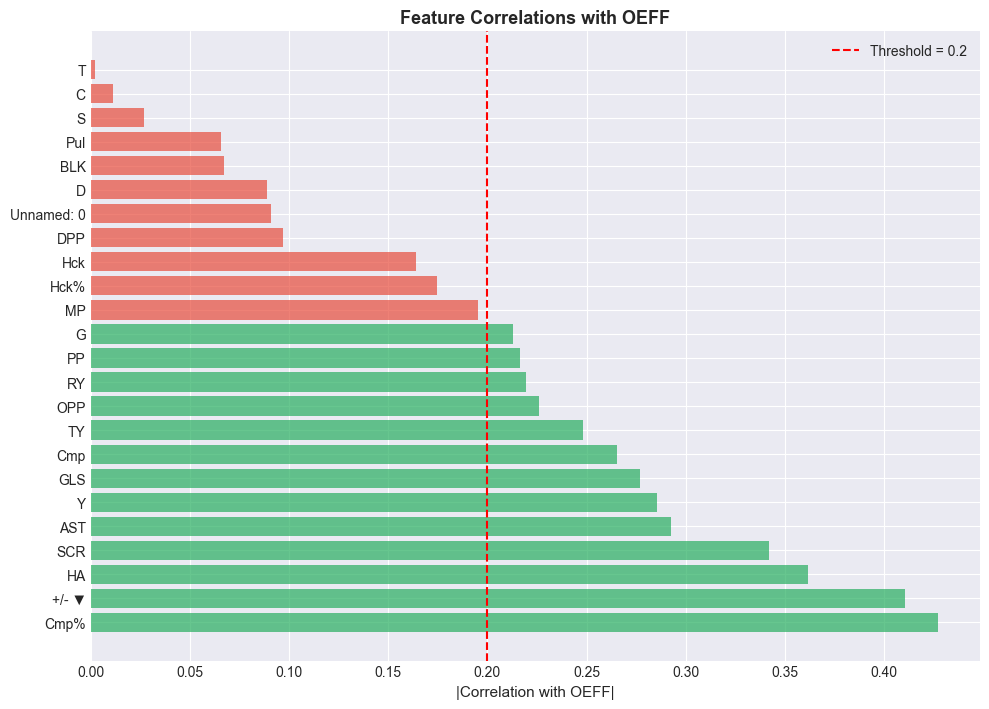


BASELINE MODELS (All Features)

Evaluating 5 models with 13 features...

  LinearRegression          R² = 0.3657  |  RMSE = 6.4010
  Ridge(α=1)                R² = 0.3657  |  RMSE = 6.4007
  Lasso(α=0.01)             R² = 0.3657  |  RMSE = 6.4007
  RandomForest              R² = 0.4259  |  RMSE = 6.0861
  GradientBoosting          R² = 0.4517  |  RMSE = 5.9496


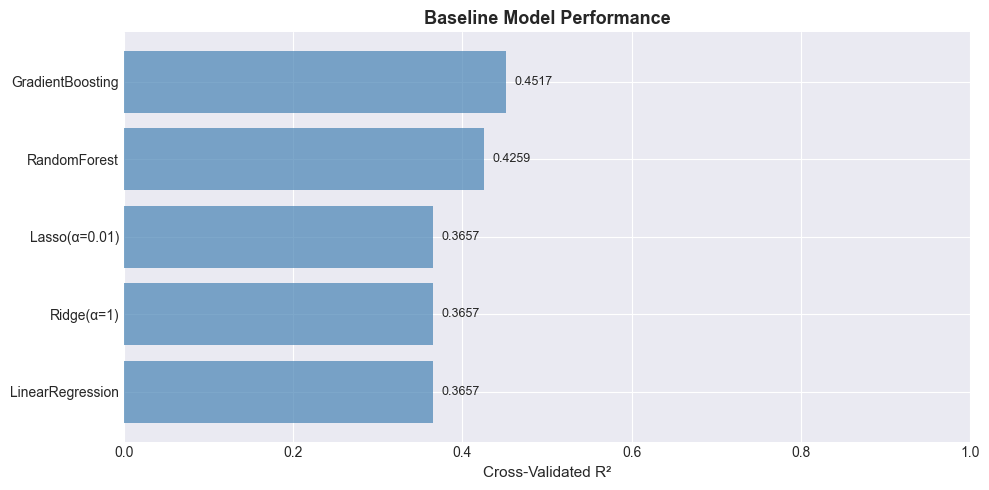


FEATURE IMPORTANCE ANALYSIS

Feature Importances:
+/- ▼    0.222443
Cmp%     0.208714
OPP      0.079399
PP       0.076277
G        0.060310
TY       0.054022
HA       0.048619
SCR      0.047438
RY       0.046994
AST      0.046686
Cmp      0.042498
Y        0.035846
GLS      0.030753

✓ Top 8 features selected for subset search: ['+/- ▼', 'Cmp%', 'OPP', 'PP', 'G', 'TY', 'HA', 'SCR']


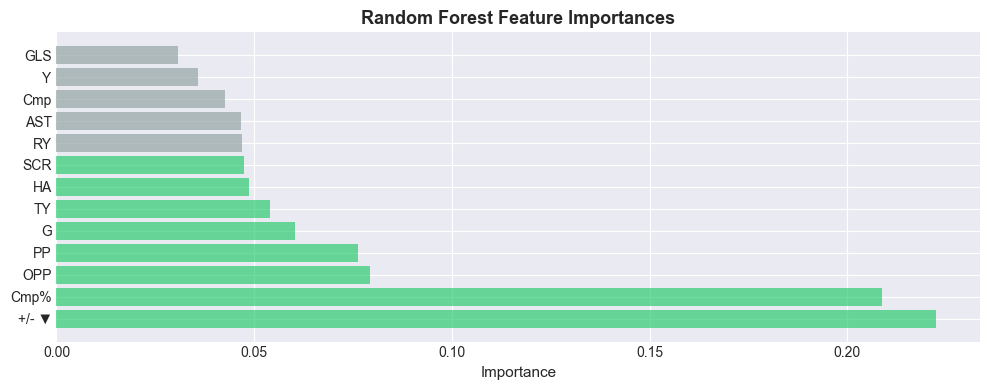


FEATURE SUBSET SEARCH (mode: forward)

Running forward selection with 3 models...
  → LinearRegression...
  → Ridge(α=1)...
  → RandomForest...
✓ Forward selection complete (108 evaluations)

🏆 BEST MODEL FOUND:
   Model: RandomForest
   Features (7): ['+/- ▼', 'Cmp%', 'OPP', 'TY', 'G', 'PP', 'HA']
   CV R² = 0.4247
   CV RMSE = 6.0931

📊 Top 10 Feature Combinations:
   0.4247 | RandomForest         | 7 features: +/- ▼, Cmp%, OPP...
   0.4237 | RandomForest         | 8 features: +/- ▼, Cmp%, OPP...
   0.4140 | RandomForest         | 6 features: +/- ▼, Cmp%, OPP...
   0.4120 | RandomForest         | 7 features: +/- ▼, Cmp%, OPP...
   0.4103 | RandomForest         | 6 features: +/- ▼, Cmp%, OPP...
   0.4010 | RandomForest         | 6 features: +/- ▼, Cmp%, OPP...
   0.3958 | RandomForest         | 5 features: +/- ▼, Cmp%, OPP...
   0.3844 | RandomForest         | 5 features: +/- ▼, Cmp%, OPP...
   0.3672 | RandomForest         | 5 features: +/- ▼, Cmp%, OPP...
   0.3613 | RandomForest  

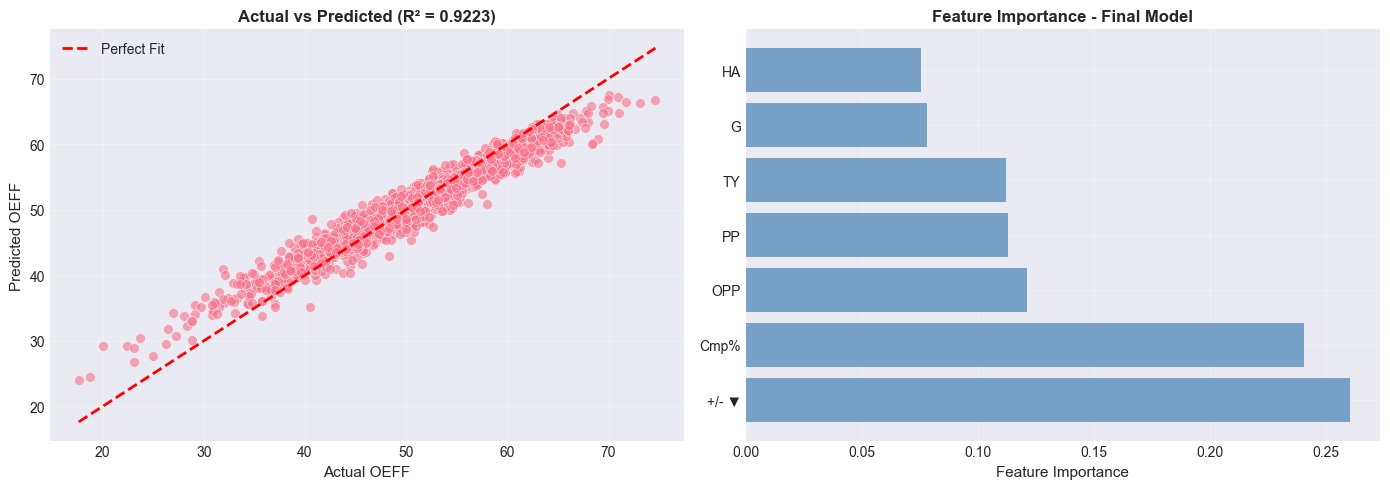


GENERATING PLAYER PREDICTIONS

✓ 2149 / 2149 players have all required features
✓ Predictions saved to: player_predictions.csv

📊 Prediction Summary (players with actual OEFF):
   Mean Absolute Error: 2.6585
   Mean Percent Error:  5.88%
   Std of Residuals:    4.2434

🔼 Top 5 Over-Performers (Actual > Predicted):
       Player         Team  OEFF_Actual  OEFF_Predicted  OEFF_Residual
Thomas Hansen thunderbirds        63.16        35.44635       27.71365
 Adrian Golay    alleycats        67.65        42.17205       25.47795
  Collin Gall     growlers        57.89        34.10780       23.78220
  Alex Thomas thunderbirds        71.74        48.85795       22.88205
 Jac Carreiro        glory        66.67        45.03385       21.63615

🔽 Top 5 Under-Performers (Actual < Predicted):
        Player     Team  OEFF_Actual  OEFF_Predicted  OEFF_Residual
    Patrick Xu  spiders        29.69        53.96255      -24.27255
Colin Ringwood mechanix        20.19        43.72245      -23.53245
 Terr

In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# USAGE EXAMPLES
# ═══════════════════════════════════════════════════════════════════════════════

# EXAMPLE 1: Run complete analysis (includes PDF generation)
results = run_complete_analysis('data.csv')

# EXAMPLE 2: Access the outputs
final_model = results['final_model']
scaler = results['scaler']
features = results['metrics']['features']
predictions = results['predictions']
pdf_report = results['pdf_report']  # Path to the generated PDF

# EXAMPLE 3: Predict for a new player
new_player = {
    'G': 15,
    'A': 8,
    'D': 2,
    '+/- ▼': 12,
    'Cmp%': 0.85,
    'OPP': 30,
    'SCR': 5,
    'PP': 3,
    'RY': 120,
    'AST': 6,
    'TY': 45,   # ← add this
    'HA': 3,    # ← add this
}
prediction = predict_new_player(new_player, final_model, scaler, features)
print(f"Predicted OEFF: {prediction:.2f}")

# EXAMPLE 4: Save model for later use
save_model(final_model, scaler, results['metrics'], 'oeff_model.pkl')

# EXAMPLE 5: Load saved model
model_package = load_model('oeff_model.pkl')

# EXAMPLE 6: View specific predictions
top_players = results['predictions'].nlargest(10, 'OEFF_Predicted')
print(top_players[['Player', 'Team', 'OEFF_Predicted']])

In [15]:
os.startfile('oeff_model_report.pdf')
os.startfile('player_predictions.csv')

In [ ]:
# Some of the regressions are better with more variables (Look at baseball versions for help)

In [16]:
# Code doesn't work correctly
# Ranks people with little to no points highly
# Limit hecht (Don't say it is offensive effieciency) + Make it a value score (Find something to include defense)
# Add blocks into it and reduce players who haven't played as much (Shrinking)

In [ ]:
# Look into random tree depth (Say it is training too much to 'training data')